# Case-control comparison of spatial co-localization with COHALU

**Author:** Jun Inamo (juninamo@keio.jp)

This tutorial shows how to test whether the spatial co-localization of cell types differs between **cases and controls**. Spatial transcriptomics studies usually have a handful of patients per group and several images (fields of view, FOVs) per patient. With that design, *which score you compare* and *what you treat as the independent unit* matter as much as the test itself.

The workflow is:

1. Compute a co-localization score **per image** with a `*_per_sample()` helper.
2. Choose a score that is comparable across images (`log2_oe`, not the raw z-score).
3. Test **patients, not images**: aggregate to patient level, or model images nested in patients.
4. Adjust for multiple testing across cell-type pairs and visualize.

All data here are simulated, so we know the ground truth: `cell_type_1` and `cell_type_2` are co-localized more strongly in cases than in controls, and nothing else differs.

**Contents**

1. Setup
2. Simulate a case-control cohort
3. Per-image neighborhood enrichment
4. Which score to compare: z-score vs log2(observed / expected)
5. Patient-level summaries and sanity checks
6. Testing case vs control
7. Why images must not be treated as independent
8. Other co-localization metrics
9. Study design: how many patients?
10. Checklist

## 1. Setup

Inside a clone of the repository, the development version is loaded with `devtools::load_all()`. Otherwise, install the package with `devtools::install_github("juninamo/COHALU")` and call `library(cohalu)`.

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  if (file.exists("../DESCRIPTION")) {
    devtools::load_all("..", quiet = TRUE)
  } else {
    library(cohalu)
  }
  library(ggplot2)
  library(patchwork)
}))

options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 130)

# Colors used throughout: one hue per group, one per highlighted cell type.
group_cols <- c(control = "#2a78d6", case = "#eb6834")
type_cols  <- c(cell_type_1 = "#4a3aa7", cell_type_2 = "#1baf7a", other = "grey85")
short <- function(x) sub("cell_type_", "T", x)   # compact axis labels

theme_tut <- theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold"),
        plot.title.position = "plot")

### A quick check of the permutation null

`nhood_enrichment()` compares the observed number of neighbor edges between two cell types with a label-permutation null. If cells are placed completely at random, the z-scores should look like draws from N(0, 1) for **every** pair, same-type pairs (the diagonal) included. This is the first thing to check before comparing groups. Use many tissues for this check: there are only K same-type pairs per tissue (8 here), so with a few tissues the diagonal histogram looks irregular by chance alone. Below, 80 random tissues give 640 same-type and 4,480 different-type values, and the actual test (`pvalue < 0.05`) is checked as well: it should be about 5% for both.

> **Note.** COHALU ≤ 0.99.1 shuffled the row and column labels *independently*, so each cell had two different labels in the null. Under spatial randomness that inflated same-type z-scores to about +11 and pushed different-type z-scores to about −2. The current version uses a single permutation for rows and columns. z-scores from earlier versions are not comparable with those below.

pair,z
<chr>,"<dbl[,3]>"
different types,"4480, 0.01, 1.01"
same type (diagonal),"640, -0.04, 0.99"


pair,p
<chr>,<dbl>
different types,0.046
same type (diagonal),0.045


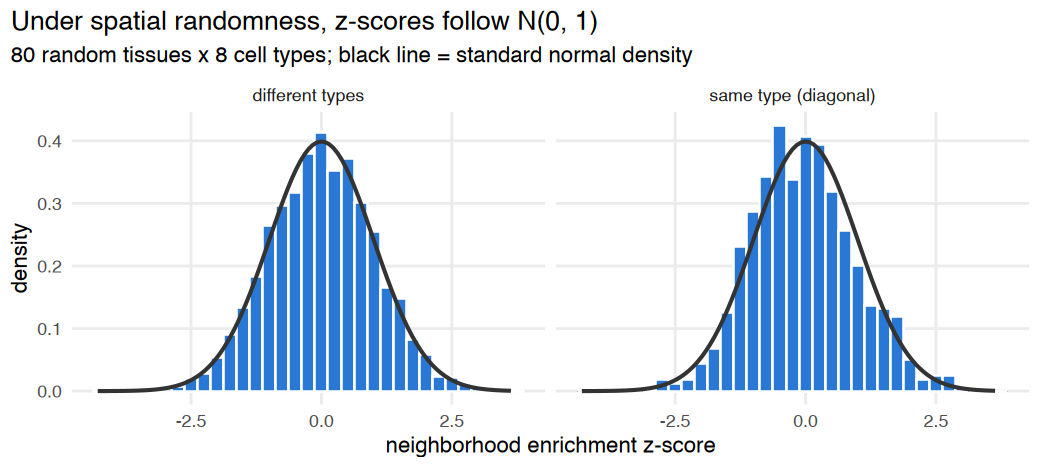

In [2]:
set.seed(1)
# 80 random tissues x 8 cell types: 640 same-type and 4,480 different-type z-scores
null_runs <- lapply(1:80, function(r) {
  n <- 1500
  d <- data.frame(x = runif(n, 0, 600), y = runif(n, 0, 600),
                  cell_type = factor(sample(paste0("cell_type_", 1:8), n, replace = TRUE)))
  rownames(d) <- paste0("r", r, "_c", seq_len(n))
  nhood_enrichment(d, cluster_key = "cell_type", neighbors.k = 10,
                   n_perms = 200, seed = r, n_jobs = 1)
})
null_z <- do.call(rbind, lapply(null_runs, function(o) {
  z <- o$zscore
  data.frame(z = c(z), pair = ifelse(c(row(z) == col(z)), "same type (diagonal)", "different types"))
}))
aggregate(z ~ pair, data = null_z, FUN = function(v) round(c(n = length(v), mean = mean(v), sd = sd(v)), 2))

# the actual test: share of pairs with pvalue < 0.05 (should be about 5%)
null_p <- do.call(rbind, lapply(null_runs, function(o) {
  up <- upper.tri(o$pvalue, diag = TRUE)
  data.frame(p = o$pvalue[up], pair = ifelse(row(o$pvalue)[up] == col(o$pvalue)[up], "same type (diagonal)", "different types"))
}))
aggregate(p ~ pair, data = null_p, FUN = function(v) round(mean(v < 0.05), 3))

options(repr.plot.width = 8, repr.plot.height = 3.6)
ggplot(null_z, aes(z)) +
  geom_histogram(aes(y = after_stat(density)), binwidth = 0.25, fill = "#2a78d6", color = "white") +
  stat_function(fun = dnorm, linewidth = 0.8, color = "grey20") +
  facet_wrap(~ pair) +
  labs(title = "Under spatial randomness, z-scores follow N(0, 1)",
       subtitle = "80 random tissues x 8 cell types; black line = standard normal density",
       x = "neighborhood enrichment z-score", y = "density") +
  theme_tut

## 2. Simulate a case-control cohort

`generate_sim_groups()` simulates **8 case and 8 control patients with 3 images each** (48 images). With `test_type = "distribute"`, a fraction `close_ratio` of `cell_type_2` cells is placed about `distance_param` away from a `cell_type_1` cell, and every other cell is placed at random.

* Cases have `close_ratio = 0.5`, controls `0.2`. Controls also show some co-localization, as healthy tissue usually does.
* `between_sample_noise = 0.1` gives each patient its own `close_ratio` (between-patient heterogeneity).
* `within_patient_noise = 0.05` adds smaller image-to-image variation within a patient.

This two-level structure (images nested in patients) is exactly what real data look like.

In [3]:
cohort <- generate_sim_groups(
  n_samples_per_group  = 8,
  group_close_ratio    = list(case = 0.5, control = 0.2),
  n_types              = 8,
  n_cells              = 1200,
  max_loc              = 500,
  test_type            = "distribute",
  distance_param       = 10,
  between_sample_noise = 0.10,
  n_images_per_patient = 3,
  within_patient_noise = 0.05,
  seed                 = 2026
)
cohort$group <- factor(cohort$group, levels = c("control", "case"))
head(cohort)

design <- unique(cohort[, c("sample_id", "patient", "group")])
data.frame(patients = tapply(design$patient, design$group, function(p) length(unique(p))),
           images   = tapply(design$sample_id, design$group, length))

,x,y,cell_type,sample_id,group,patient
,<dbl>,<dbl>,<fct>,<chr>,<fct>,<chr>
case_1_img1_cell1,290.4731,348.42084,cell_type_5,case_1_img1,case,case_1
case_1_img1_cell2,275.4035,171.44057,cell_type_6,case_1_img1,case,case_1
case_1_img1_cell3,46.1745,129.48926,cell_type_1,case_1_img1,case,case_1
case_1_img1_cell4,303.7893,283.31119,cell_type_5,case_1_img1,case,case_1
case_1_img1_cell5,395.5516,94.18104,cell_type_7,case_1_img1,case,case_1
case_1_img1_cell6,270.5713,376.07537,cell_type_2,case_1_img1,case,case_1


,patients,images
,<int>,<int>
control,8,24
case,8,24


A 200 × 200 window of one image for each of four cases and four controls, with the two cell types of interest highlighted. Cases have more violet-green pairs sitting next to each other. Even so, the difference is subtle by eye, which is why it has to be quantified.

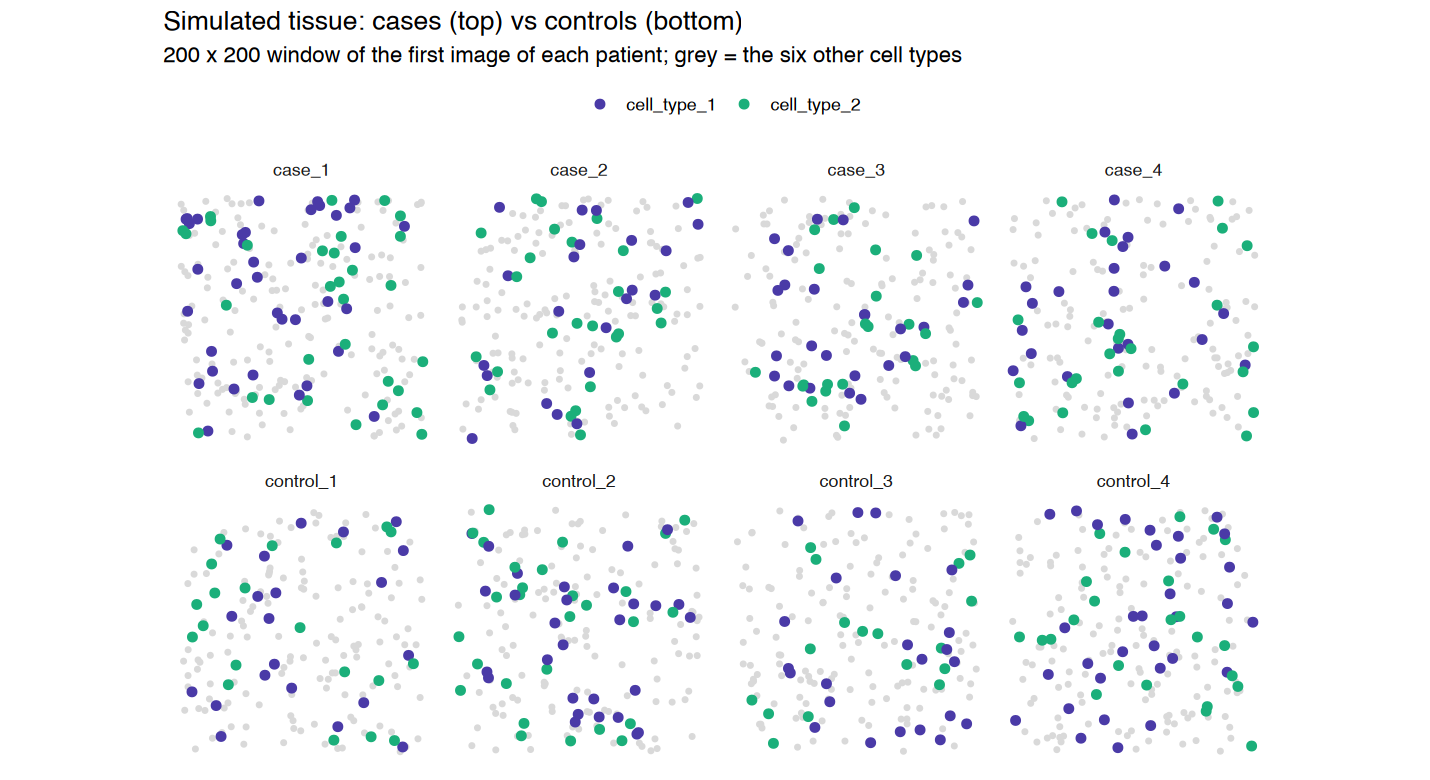

In [4]:
show_ids <- c(paste0("case_", 1:4, "_img1"), paste0("control_", 1:4, "_img1"))
map_df <- subset(cohort, sample_id %in% show_ids & x < 200 & y < 200)
map_df$highlight <- ifelse(as.character(map_df$cell_type) %in% c("cell_type_1", "cell_type_2"),
                           as.character(map_df$cell_type), "other")
map_df$panel <- factor(sub("_img1", "", map_df$sample_id), levels = sub("_img1", "", show_ids))

options(repr.plot.width = 11, repr.plot.height = 6)
ggplot(map_df, aes(x, y)) +
  geom_point(data = subset(map_df, highlight == "other"), color = type_cols[["other"]], size = 0.8) +
  geom_point(data = subset(map_df, highlight != "other"), aes(color = highlight), size = 1.8) +
  facet_wrap(~ panel, nrow = 2) +
  scale_color_manual(values = type_cols[1:2], name = NULL) +
  coord_equal() +
  labs(title = "Simulated tissue: cases (top) vs controls (bottom)",
       subtitle = "200 x 200 window of the first image of each patient; grey = the six other cell types", x = NULL, y = NULL) +
  theme_tut +
  theme(axis.text = element_blank(), panel.grid = element_blank(), legend.position = "top")

## 3. Per-image neighborhood enrichment

`nhood_enrichment_per_sample()` runs the permutation test separately in every image. Labels are shuffled **within** an image, so the null keeps that image's cell-type composition. Cell-type levels are harmonized across images, so a cell type missing from one image gives `NA` instead of a misaligned matrix.

The input can be a long data.frame (as here), a Seurat object with one FOV per image, or a list of Seurat objects. For Seurat input, images are matched to `meta.data` by cell name, so `sample_key` values do not need to equal the image names.

In [5]:
t0 <- Sys.time()
per_image <- nhood_enrichment_per_sample(
  cohort,
  sample_key  = "sample_id",
  group_key   = "group",
  cluster_key = "cell_type",
  patient_key = "patient",
  neighbors.k = 10,
  n_perms     = 200,
  n_jobs      = 1,
  seed        = 1
)
Sys.time() - t0
head(per_image[order(per_image$sample_id), ], 4)

Time difference of 14.26745 secs

,sample_id,cluster_i,cluster_j,zscore,count,expected,log2_oe,group,patient,n_cells,n_i,n_j
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>,<int>
1,case_1_img1,cell_type_1,cell_type_1,-1.79535546,36.59245,39.69216,-0.1156676619,case,case_1,1200,177,177
2,case_1_img1,cell_type_2,cell_type_1,2.42332465,23.02136,19.78173,0.2210913979,case,case_1,1200,154,177
3,case_1_img1,cell_type_3,cell_type_1,-0.02485323,18.91202,18.94504,0.0009870095,case,case_1,1200,149,177
4,case_1_img1,cell_type_4,cell_type_1,-0.59872946,14.14555,14.84565,-0.0647837528,case,case_1,1200,115,177


One row per `image x cluster_i x cluster_j`:

| column | meaning |
|---|---|
| `count` | observed (degree-normalized) number of neighbor edges between the two types |
| `expected` | mean count over label permutations: what composition alone predicts |
| `zscore` | (count - expected) / SD of the permutations: the **evidence** for enrichment within this image |
| `log2_oe` | log2(count / expected): the **size** of the enrichment |
| `n_cells`, `n_i`, `n_j` | total cells and cells of each of the two types in the image |

## 4. Which score to compare: z-score vs log2(observed / expected)

A z-score is a signal-to-noise ratio. For the same spatial pattern, it grows roughly with the **square root of the number of cells**, because the permutation SD shrinks as more cells are counted. Real case and control images often differ in size or cell density (inflamed tissue is more cellular, biopsies differ in area). If they do, comparing z-scores confounds tissue size with co-localization.

To show this, simulate a cohort with **no true difference**: both groups have `close_ratio = 0.35`. The only difference is that case images contain 4x more cells (the same density over a larger area).

In [6]:
size_cohort <- generate_sim_groups(
  n_samples_per_group  = 8,
  group_close_ratio    = list(case = 0.35, control = 0.35),   # no true difference
  n_types              = 8,
  n_cells              = list(case = 3200, control = 800),    # case images are 4x larger
  max_loc              = 410,                                  # scaled to keep density constant
  test_type            = "distribute",
  distance_param       = 10,
  between_sample_noise = 0.05,
  seed                 = 7
)
size_scores <- nhood_enrichment_per_sample(
  size_cohort, sample_key = "sample_id", group_key = "group",
  cluster_key = "cell_type", patient_key = "patient",
  neighbors.k = 10, n_perms = 200, n_jobs = 1, seed = 1
)

tgt <- function(d) subset(d, cluster_i == "cell_type_1" & cluster_j == "cell_type_2")
size_tgt <- tgt(size_scores)
size_tgt$group <- factor(size_tgt$group, levels = c("control", "case"))

size_tests <- do.call(rbind, lapply(c("zscore", "log2_oe"), function(v) {
  r <- tgt(compare_groups(size_scores, value = v, method = "wilcox", ref_group = "control"))
  data.frame(score = v, effect = signif(r$effect, 3), p = signif(r$p, 3))
}))
size_tests

score,effect,p
<chr>,<dbl>,<dbl>
zscore,2.0600,0.0104
log2_oe,0.0313,0.7980


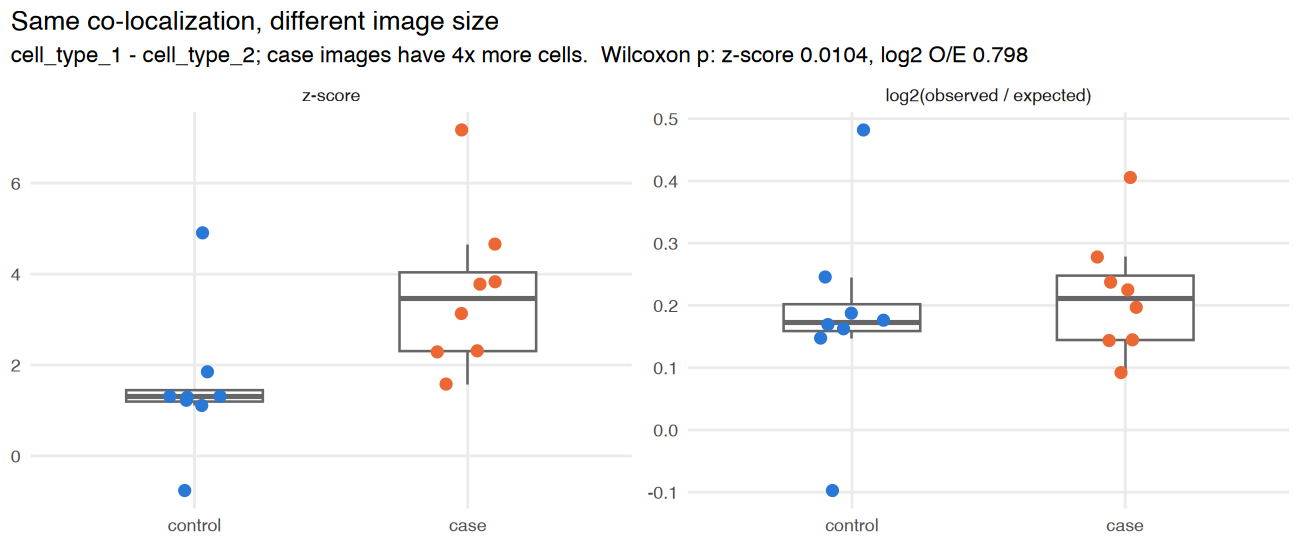

In [7]:
size_long <- rbind(
  data.frame(size_tgt[, c("group", "n_cells")], score = "z-score", value = size_tgt$zscore),
  data.frame(size_tgt[, c("group", "n_cells")], score = "log2(observed / expected)", value = size_tgt$log2_oe)
)
size_long$score <- factor(size_long$score, levels = c("z-score", "log2(observed / expected)"))

options(repr.plot.width = 10, repr.plot.height = 4.2)
ggplot(size_long, aes(group, value, color = group)) +
  geom_boxplot(outlier.shape = NA, width = 0.5, color = "grey40") +
  geom_jitter(width = 0.12, size = 2.4) +
  facet_wrap(~ score, scales = "free_y") +
  scale_color_manual(values = group_cols, guide = "none") +
  labs(title = "Same co-localization, different image size",
       subtitle = sprintf("cell_type_1 - cell_type_2; case images have 4x more cells.  Wilcoxon p: z-score %.3g, log2 O/E %.3g",
                          size_tests$p[1], size_tests$p[2]),
       x = NULL, y = NULL) +
  theme_tut

The z-score reports a highly significant difference that does not exist. `log2_oe` measures *how much* more often the two types touch than expected, so it barely moves with image size, and the difference is not significant. The small residual shift is an edge effect: in smaller images a larger share of cells sit at the border and lose neighbors there.

**Recommendation:** compare `log2_oe` between groups. Use the z-score to judge whether enrichment exists within a sample, not to rank or compare samples. Never compare raw `count`: it also scales with how abundant the two cell types are.

`log2_oe` is still conditional on composition (the permutation null keeps each image's cell-type proportions). A change in co-localization is therefore reported separately from a change in abundance. Check abundance yourself with `n_i` / `n_j`.

## 5. Patient-level summaries and sanity checks

`summarize_by_patient()` averages image-level scores within each patient. It gives one value per patient for each pair and recomputes no permutations. This is what `unit = "patient"` does inside the `*_per_sample()` helpers.

In [8]:
per_patient <- summarize_by_patient(per_image)
per_patient$group <- factor(per_patient$group, levels = c("control", "case"))
dim(per_image); dim(per_patient)

[1] 3072   12

[1] 1024   12

Before any test, look at the group-average `log2_oe` for every pair. The planted pair should stand out in cases.

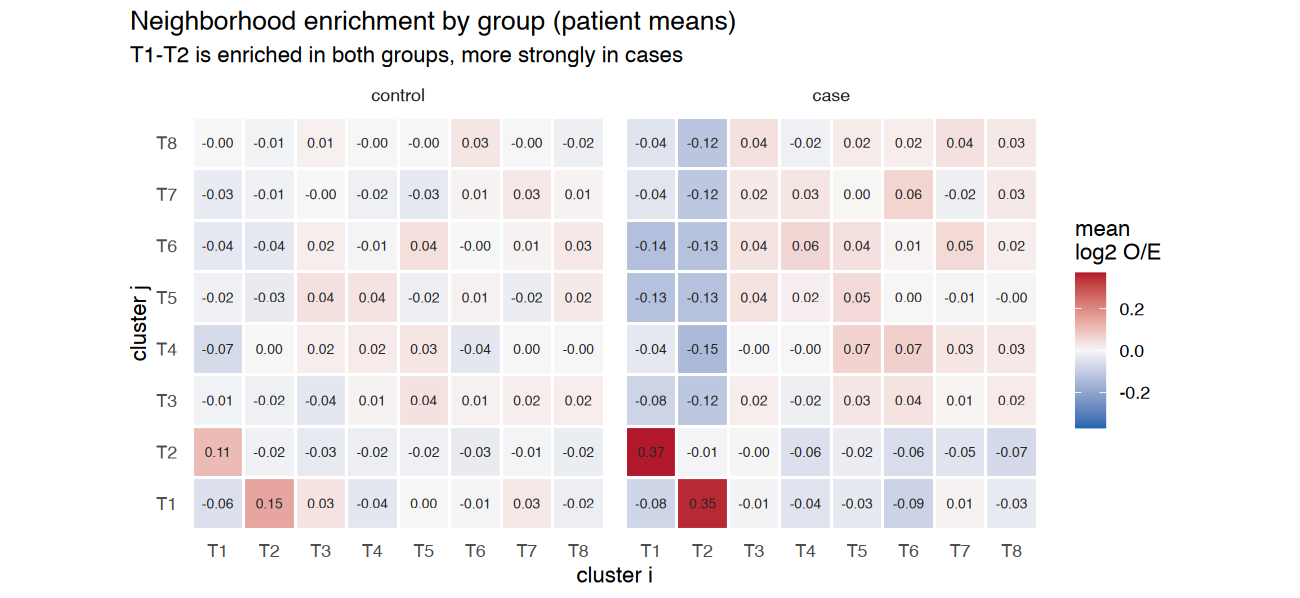

In [9]:
hm <- aggregate(log2_oe ~ cluster_i + cluster_j + group, data = per_patient, FUN = mean)
hm$cluster_i <- short(hm$cluster_i); hm$cluster_j <- short(hm$cluster_j)
lim <- max(abs(hm$log2_oe))

options(repr.plot.width = 10, repr.plot.height = 4.6)
ggplot(hm, aes(cluster_i, cluster_j, fill = log2_oe)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = sprintf("%.2f", log2_oe)), size = 2.6, color = "grey15") +
  facet_wrap(~ group) +
  scale_fill_gradient2(low = "#2166AC", mid = "grey97", high = "#B2182B",
                       midpoint = 0, limits = c(-lim, lim), name = "mean\nlog2 O/E") +
  coord_equal() +
  labs(title = "Neighborhood enrichment by group (patient means)",
       subtitle = "T1-T2 is enriched in both groups, more strongly in cases",
       x = "cluster i", y = "cluster j") +
  theme_tut + theme(panel.grid = element_blank())

## 6. Testing case vs control

Three strategies respect the fact that patients, not images, are independent. Each is one call to `compare_groups()`:

| strategy | input | call |
|---|---|---|
| Patient-level Wilcoxon | one value per patient | `compare_groups(per_patient, method = "wilcox")` |
| Linear mixed model | all images | `compare_groups(per_image, method = "lmm", patient_key = "patient")` |
| Patient-blocked permutation | all images | `compare_groups(per_image, method = "perm", patient_key = "patient")` |

Always set `ref_group = "control"` so that `effect = mean(case) - mean(control)`. Without it the reference is chosen alphabetically, and `"case"` sorts before `"control"`. Use `symmetric = TRUE` to test each unordered pair once: (T1, T2) and (T2, T1) carry the same information, and testing both doubles the multiple-testing burden.

For the LMM, p-values use Satterthwaite degrees of freedom when **lmerTest** is installed. Wald z-tests are anti-conservative with the small numbers of patients typical in spatial studies.

In [10]:
res_wilcox <- compare_groups(per_patient, value = "log2_oe", method = "wilcox",
                             ref_group = "control", symmetric = TRUE)
res_lmm    <- compare_groups(per_image, value = "log2_oe", method = "lmm",
                             patient_key = "patient", ref_group = "control", symmetric = TRUE)
res_perm   <- compare_groups(per_image, value = "log2_oe", method = "perm",
                             patient_key = "patient", ref_group = "control", symmetric = TRUE,
                             n_perms = 5000)
attr(res_lmm, "p_method")

cols <- c("cluster_i", "cluster_j", "effect", "p", "padj")
head(res_lmm[, c(cols[1:3], "estimate", cols[4:5])], 8)

[1] "LMM, Satterthwaite df (lmerTest)"

,cluster_i,cluster_j,effect,estimate,p,padj
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,cell_type_1,cell_type_2,0.23421766,0.23421766,0.0001839993,0.006623974
2,cell_type_5,cell_type_5,0.07059004,0.07059004,0.0011341037,0.020413867
3,cell_type_2,cell_type_4,-0.09248981,-0.09248981,0.0068634564,0.065588885
4,cell_type_4,cell_type_6,0.08643789,0.08643789,0.0072876539,0.065588885
5,cell_type_1,cell_type_5,-0.07413566,-0.07413566,0.0122984323,0.088548713
6,cell_type_2,cell_type_7,-0.06985906,-0.06985906,0.0155709422,0.093425653
7,cell_type_3,cell_type_3,0.05571945,0.05571945,0.0280125042,0.143850074
8,cell_type_1,cell_type_6,-0.08979510,-0.08979510,0.0319666831,0.143850074


In [11]:
summary_tbl <- do.call(rbind, lapply(
  list("Wilcoxon, patient level" = res_wilcox, "LMM, images in patients" = res_lmm,
       "Permutation, patient-blocked" = res_perm),
  function(r) tgt(r)[, c("effect", "p", "padj")]))
signif(summary_tbl, 3)

,effect,p,padj
,<dbl>,<dbl>,<dbl>
"Wilcoxon, patient level",0.234,0.000622,0.01120
"LMM, images in patients",0.234,0.000184,0.00662
"Permutation, patient-blocked",0.234,0.000400,0.00720


All three strategies detect the planted T1-T2 difference after BH correction and agree on the effect size. The volcano plot shows every pair at once:

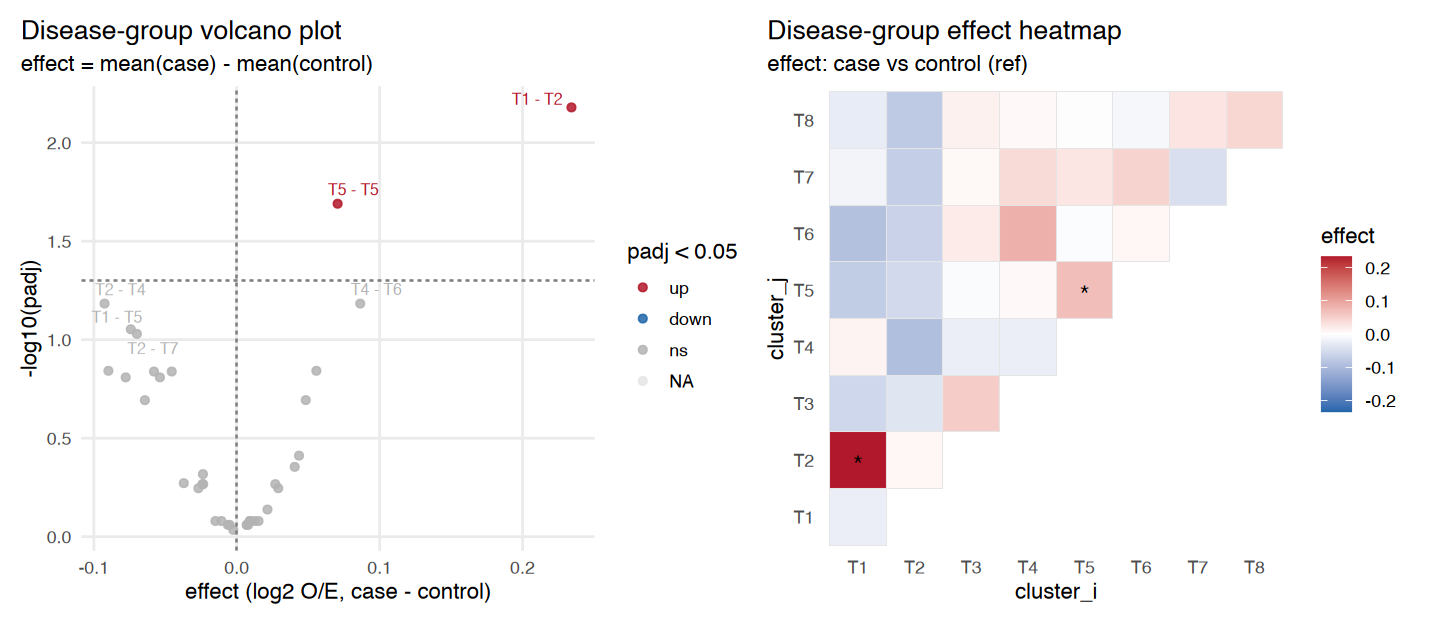

In [12]:
options(repr.plot.width = 11, repr.plot.height = 4.8)
vol <- res_lmm
vol$cluster_i <- short(vol$cluster_i); vol$cluster_j <- short(vol$cluster_j)
dh <- res_lmm
dh$cluster_i <- short(dh$cluster_i); dh$cluster_j <- short(dh$cluster_j)

plot_volcano_groups(vol, label_top = 6) + theme_tut + labs(x = "effect (log2 O/E, case - control)") |
  plot_group_delta_heatmap(dh) + theme_tut + theme(panel.grid = element_blank())

Only T1-T2 was planted, so every other pair that passes BH is a **false discovery or a side effect**, and it is worth knowing both:

* **Side effect of the planted pair.** Within-image scores are relative. When more T2 cells sit right next to T1 cells, T1 and T2 have fewer neighbours of every other type (blue in the heatmap), and the remaining cell types become slightly more likely to neighbour each other. Across 160 simulated images this shift is small: about +0.01 to +0.02 log2 O/E for pairs among T3-T8, and about -0.08 for T1 or T2 with a third type.
* **Chance.** Benjamini-Hochberg controls the *false discovery rate*: on average about 5% of the pairs called significant are expected to be false, and with only a few discoveries a single false one is common.

In this run T5-T5 (effect +0.07, far smaller than T1-T2) passes BH although nothing was planted for T5; it is most likely chance on top of the small relative shift. Read such pairs as consequences of the main change or as candidates to confirm, not as independent findings, and look at their effect size and per-patient values.

Always plot the per-patient values behind a hit. Large points are patient means, small points the individual images:

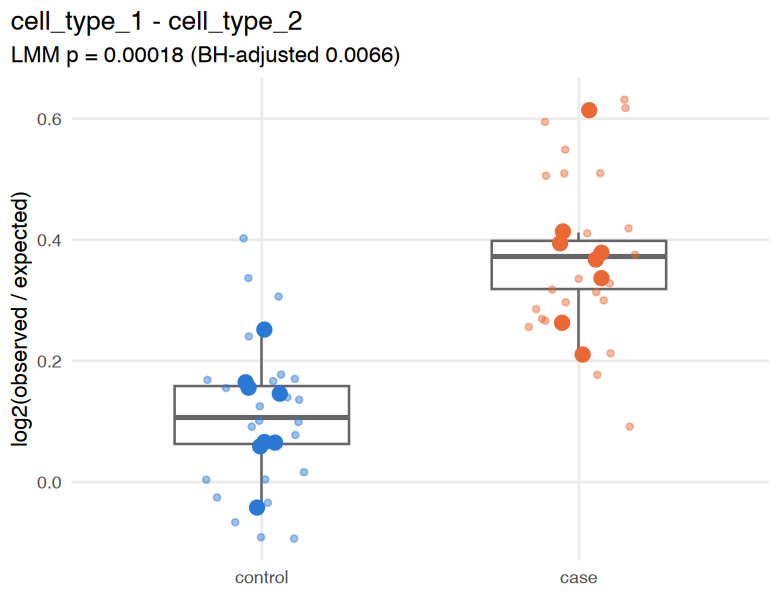

In [13]:
img_t <- tgt(per_image);   img_t$group <- factor(img_t$group, levels = c("control", "case"))
pat_t <- tgt(per_patient)

options(repr.plot.width = 6, repr.plot.height = 4.6)
ggplot(pat_t, aes(group, log2_oe, color = group)) +
  geom_boxplot(outlier.shape = NA, width = 0.55, color = "grey40") +
  geom_point(data = img_t, position = position_jitter(width = 0.18, seed = 1),
             size = 1.2, alpha = 0.45) +
  geom_point(position = position_jitter(width = 0.08, seed = 2), size = 3.2) +
  scale_color_manual(values = group_cols, guide = "none") +
  labs(title = "cell_type_1 - cell_type_2",
       subtitle = sprintf("LMM p = %.2g (BH-adjusted %.2g)", tgt(res_lmm)$p, tgt(res_lmm)$padj),
       x = NULL, y = "log2(observed / expected)") +
  theme_tut

### Adjusting for covariates

With `method = "lmm"`, extra fixed effects go in through `covariates`: age, sex, processing batch, or the abundance of the two cell types. Covariates are ordinary columns of the per-sample table, so merge patient metadata first. `estimate` is then the covariate-adjusted case effect, and `effect` stays the raw mean difference.

In [14]:
set.seed(3)
batch_tbl <- data.frame(patient = unique(per_image$patient))
batch_tbl$batch <- sample(c("run1", "run2"), nrow(batch_tbl), replace = TRUE)
per_image_b <- merge(per_image, batch_tbl, by = "patient")

res_adj <- compare_groups(per_image_b, value = "log2_oe", method = "lmm",
                          patient_key = "patient", covariates = c("batch", "n_cells"),
                          ref_group = "control", symmetric = TRUE)
signif(tgt(res_adj)[, c("effect", "estimate", "p", "padj")], 3)

,effect,estimate,p,padj
,<dbl>,<dbl>,<dbl>,<dbl>
1,0.234,0.241,0.000195,0.00702


## 7. Why images must not be treated as independent

Images from the same patient share that patient's biology, so they are correlated. A Wilcoxon or t-test on all images acts as if there were 3x more independent observations than there are (**pseudoreplication**). `compare_groups()` therefore averages images within patients by default (`unit = "patient"`); the experiment below uses `unit = "image"` on purpose to show what goes wrong otherwise. The next experiment shows how large the problem is.

We simulate 24 patients × 4 images from **one** population with strong between-patient heterogeneity, split the patients at random into two "groups" 500 times, and record how often each strategy calls T1-T2 significant at α = 0.05. With no true difference, a valid test should reject about 5% of the time.

In [15]:
pool <- generate_sim_groups(
  n_samples_per_group = 24, group_close_ratio = list(all = 0.3),
  n_types = 8, n_cells = 800, max_loc = 410, test_type = "distribute", distance_param = 10,
  between_sample_noise = 0.15, n_images_per_patient = 4, within_patient_noise = 0.03, seed = 11
)
pool_t <- tgt(nhood_enrichment_per_sample(
  pool, sample_key = "sample_id", group_key = "group", cluster_key = "cell_type",
  patient_key = "patient", neighbors.k = 10, n_perms = 100, n_jobs = 1, seed = 1
))

pats <- unique(pool_t$patient)
set.seed(2024)
null_p <- t(replicate(500, {
  d <- pool_t
  d$group <- ifelse(d$patient %in% sample(pats, 12), "case", "control")
  q <- function(x, ...) suppressWarnings(suppressMessages(
    compare_groups(x, value = "log2_oe", ref_group = "control", ...)))$p
  c("Wilcoxon, images as units (pseudoreplication)" = q(d, method = "wilcox", unit = "image"),
    "Wilcoxon, patient level"      = q(summarize_by_patient(d), method = "wilcox"),
    "LMM, images in patients"      = q(d, method = "lmm", patient_key = "patient"),
    "Permutation, patient-blocked" = q(d, method = "perm", patient_key = "patient", n_perms = 500))
}))

fpr <- data.frame(method = colnames(null_p), rate = colMeans(null_p < 0.05))
fpr$lo <- sapply(fpr$rate, function(r) binom.test(round(r * 500), 500)$conf.int[1])
fpr$hi <- sapply(fpr$rate, function(r) binom.test(round(r * 500), 500)$conf.int[2])
fpr$method <- factor(fpr$method, levels = rev(fpr$method))
fpr

,method,rate,lo,hi
,<fct>,<dbl>,<dbl>,<dbl>
"Wilcoxon, images as units (pseudoreplication)","Wilcoxon, images as units (pseudoreplication)",0.184,0.15098874,0.22079907
"Wilcoxon, patient level","Wilcoxon, patient level",0.044,0.02777677,0.06586100
"LMM, images in patients","LMM, images in patients",0.036,0.02147286,0.05630018
"Permutation, patient-blocked","Permutation, patient-blocked",0.048,0.03099317,0.07058080


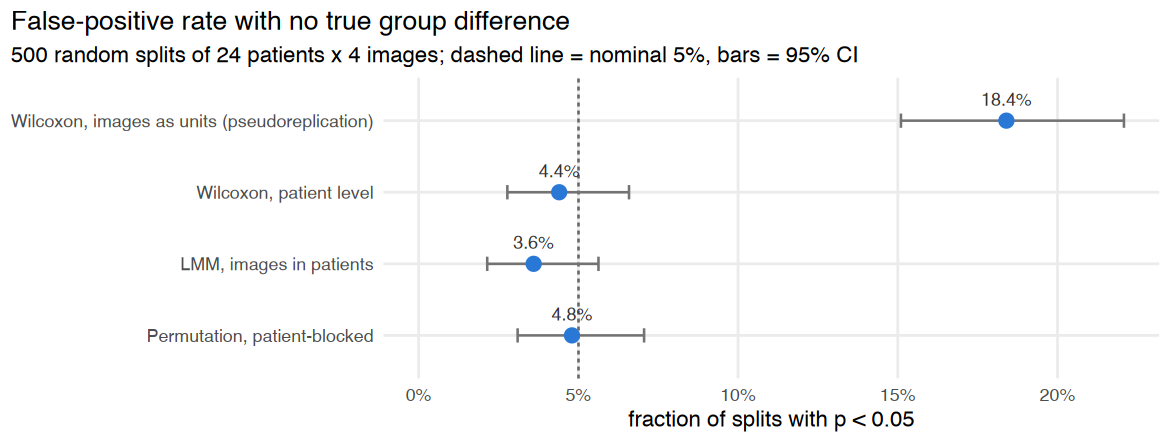

In [16]:
options(repr.plot.width = 9, repr.plot.height = 3.4)
ggplot(fpr, aes(rate, method)) +
  geom_vline(xintercept = 0.05, linetype = "dashed", color = "grey40") +
  geom_errorbarh(aes(xmin = lo, xmax = hi), height = 0.2, color = "grey45") +
  geom_point(size = 3.2, color = "#2a78d6") +
  geom_text(aes(label = sprintf("%.1f%%", 100 * rate)), nudge_y = 0.3, size = 3.4, color = "grey20") +
  scale_x_continuous(labels = scales::percent, limits = c(0, NA)) +
  labs(title = "False-positive rate with no true group difference",
       subtitle = "500 random splits of 24 patients x 4 images; dashed line = nominal 5%, bars = 95% CI",
       x = "fraction of splits with p < 0.05", y = NULL) +
  theme_tut

Treating images as independent gives about three times the nominal false-positive rate, and the gap widens with more images per patient or more between-patient heterogeneity. The three patient-aware strategies stay at or below 5%.

## 8. Other co-localization metrics

The same `*_per_sample()` → `compare_groups()` pattern works for the other scores in the package:

* `cooccur_ratio_per_sample()`: radius-based co-occurrence ratio p(j | neighbor of i) / p(j). It is normalized by composition but has no permutation null.
* `cooccur_local_per_sample()`: per-cell local co-occurrence score (sCLS), summarized per image. It has **no null model**, so its level rises with the abundance of the two cell types. Check `n_i` / `n_j`, or adjust for them as covariates, when groups differ in composition.
* `interaction_spot_per_sample()` (Seurat input): number of connected interaction spots. Compare `spots_per_1k_cells` rather than raw `n_spots` when images differ in size.

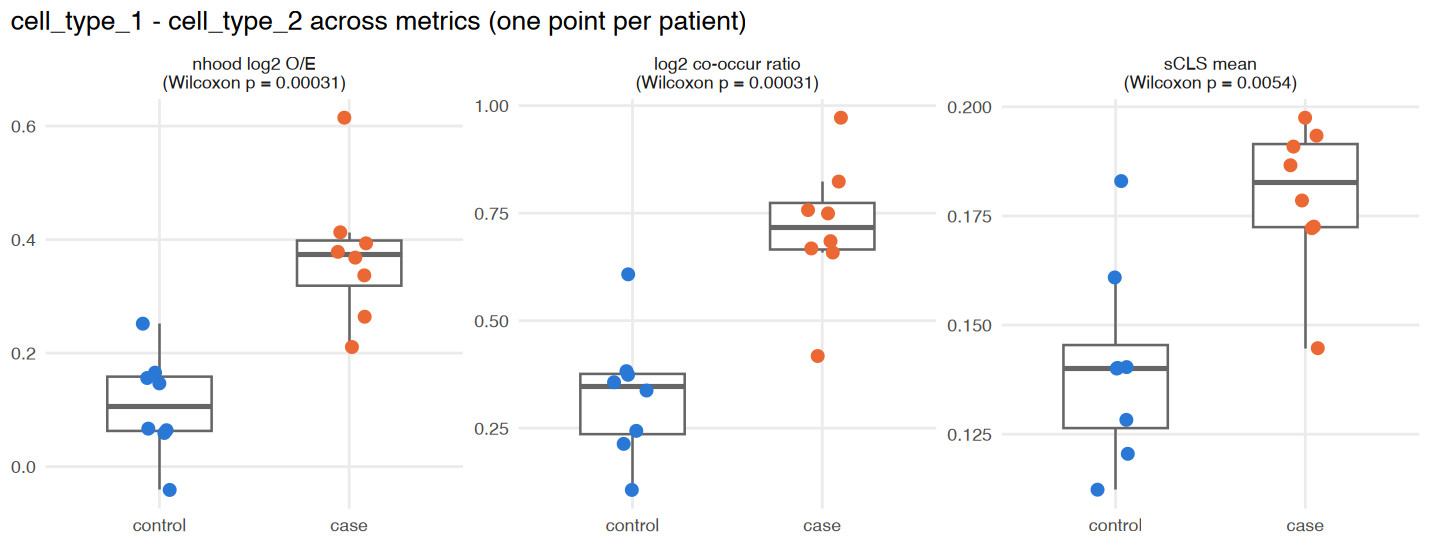

In [17]:
ratio_img <- cooccur_ratio_per_sample(
  cohort, sample_key = "sample_id", group_key = "group", cluster_key = "cell_type",
  patient_key = "patient", radius = 15, k = 50
)
local_img <- cooccur_local_per_sample(
  cohort, sample_key = "sample_id", group_key = "group", cluster_key = "cell_type",
  cluster_x = "cell_type_1", cluster_y = "cell_type_2", patient_key = "patient",
  neighbors.k = 20, radius = 15, summarize = c("mean", "pos_rate")
)
ratio_img$log2_ratio <- log2(ratio_img$ratio)

metrics <- list(
  "nhood log2 O/E"      = list(d = per_image, v = "log2_oe"),
  "log2 co-occur ratio" = list(d = ratio_img, v = "log2_ratio"),
  "sCLS mean"           = list(d = local_img, v = "mean")
)
metric_res <- do.call(rbind, lapply(names(metrics), function(m) {
  pt <- tgt(summarize_by_patient(metrics[[m]]$d))
  r  <- compare_groups(pt, value = metrics[[m]]$v, method = "wilcox", ref_group = "control")
  list(points = data.frame(metric = m, group = pt$group, value = pt[[metrics[[m]]$v]]),
       p = r$p)
}))
pts <- do.call(rbind, metric_res[, "points"])
pts$group  <- factor(pts$group, levels = c("control", "case"))
labs_p <- setNames(sprintf("%s\n(Wilcoxon p = %.2g)", names(metrics), unlist(metric_res[, "p"])), names(metrics))
pts$metric <- factor(labs_p[pts$metric], levels = labs_p)

options(repr.plot.width = 11, repr.plot.height = 4.2)
ggplot(pts, aes(group, value, color = group)) +
  geom_boxplot(outlier.shape = NA, width = 0.55, color = "grey40") +
  geom_point(position = position_jitter(width = 0.1, seed = 1), size = 2.6) +
  facet_wrap(~ metric, scales = "free_y") +
  scale_color_manual(values = group_cols, guide = "none") +
  labs(title = "cell_type_1 - cell_type_2 across metrics (one point per patient)",
       x = NULL, y = NULL) +
  theme_tut

## 9. Study design: how many patients?

With few patients, an exact rank test has a hard floor on its smallest possible p-value, regardless of how large the effect is. With 3 vs 3 patients a two-sided Wilcoxon cannot go below 0.10, so nothing can ever be significant. Testing every pair among many cell types lowers the bar further. For the single strongest hit to pass BH among M tests, its p must be below 0.05 / M.

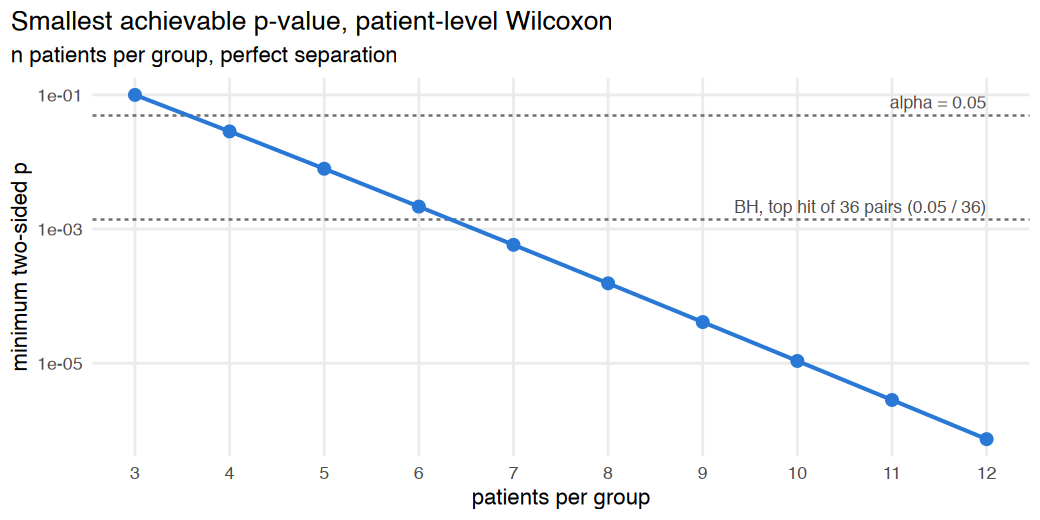

In [18]:
n <- 3:12
floor_df <- data.frame(n = n, p_min = 2 / choose(2 * n, n))   # exact two-sided Wilcoxon, n vs n
M <- choose(8, 2) + 8                                          # unordered pairs among 8 cell types
thr <- data.frame(y = c(0.05, 0.05 / M),
                  lab = c("alpha = 0.05", sprintf("BH, top hit of %d pairs (0.05 / %d)", M, M)))

options(repr.plot.width = 8, repr.plot.height = 4)
ggplot(floor_df, aes(n, p_min)) +
  geom_hline(data = thr, aes(yintercept = y), linetype = "dashed", color = "grey45") +
  geom_text(data = thr, aes(x = 12, y = y, label = lab), hjust = 1, vjust = -0.5, size = 3.3, color = "grey30") +
  geom_line(linewidth = 0.8, color = "#2a78d6") +
  geom_point(size = 2.6, color = "#2a78d6") +
  scale_y_log10() + scale_x_continuous(breaks = n) +
  labs(title = "Smallest achievable p-value, patient-level Wilcoxon",
       subtitle = "n patients per group, perfect separation",
       x = "patients per group", y = "minimum two-sided p") +
  theme_tut

Practical consequences:

* With **fewer than about 7 patients per group**, even a perfectly separated pair cannot survive BH correction over all 36 pairs. Pre-specify a small set of hypothesized pairs instead of testing all pairs, or use the LMM, which uses image-level variation and has no rank floor.
* Adding **images per patient** helps only with within-patient noise. Power is limited by the number of patients.
* Use `min_n_per_group` (default 2) to skip pairs that are observed in too few samples, e.g. because one cell type is absent from most images.

## 10. Checklist

1. **Unit of analysis = patient.** Aggregate with `summarize_by_patient()` / `unit = "patient"`, or keep images and use `method = "lmm"` or `"perm"` with `patient_key`.
2. **Compare `log2_oe`, not `zscore` or `count`.** z-scores scale with the number of cells, and counts with cell-type abundance.
3. **Set `ref_group = "control"`** so that positive `effect` means higher in cases.
4. **Use `symmetric = TRUE`** for symmetric scores, so each pair is tested once.
5. **Report abundance separately** (`n_i`, `n_j`). Co-localization and composition are different findings.
6. **Adjust for covariates** (batch, age, sex, image size) with `method = "lmm"` and `covariates`.
7. **Read depletion hits in context.** Enrichment of one partner forces depletion of others.
8. **Plot patient-level values** behind every significant pair.

## 11. Continuous clinical variables: `associate_continuous()`

Many clinical variables are continuous (CRP, disease activity, number of affected joints, age). `associate_continuous()` tests, for every cell-type pair, whether a per-image score changes with such a variable, with the patient as the unit: Spearman correlation of patient means (default), a linear model with covariates (`"lm"`), a mixed model on images (`"lmm"`) or a permutation test (`"perm"`), then Benjamini–Hochberg over pairs.

Below, 12 patients have 2 images each, and the share of type-2 cells placed next to type-1 cells rises with a patient-level variable `x`.

In [19]:
set.seed(7)
pats <- sprintf("p%02d", 1:12); x <- setNames(runif(12), pats)
cont <- do.call(rbind, lapply(pats, function(p) do.call(rbind, lapply(1:2, function(m) {
  g <- generate_sim(close_ratio = min(1, 0.2 + 0.5 * x[p] + rnorm(1, 0, 0.03)), n_types = 5, n_cells = 700,
                    max_loc = 400, test_type = "distribute", distance_param = 10, seed = sample.int(1e6, 1))
  g$sample_id <- paste0(p, "_", m); g$patient <- p; g$group <- "all"
  rownames(g) <- paste0(g$sample_id, "_", seq_len(nrow(g))); g }))))
per_image_c <- nhood_enrichment_per_sample(cont, sample_key = "sample_id", group_key = "group",
                                           cluster_key = "cell_type", patient_key = "patient",
                                           neighbors.k = 10, n_perms = 100, n_jobs = 1)
ac <- associate_continuous(per_image_c, x, value = "log2_oe", method = "spearman")
head(ac, 5)
associate_continuous(per_image_c, x, value = "log2_oe", method = "lmm")[1:3, ]

,cluster_i,cluster_j,n_patients,estimate,p,padj,method
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>
12,cell_type_2,cell_type_3,12,-0.7482517,0.005124082,0.1280649,spearman
10,cell_type_5,cell_type_2,12,-0.7062937,0.010245194,0.1280649,spearman
24,cell_type_4,cell_type_5,12,0.6713287,0.016831456,0.1402621,spearman
6,cell_type_1,cell_type_2,12,0.6433566,0.024003191,0.1415984,spearman
22,cell_type_2,cell_type_5,12,-0.6293706,0.028319671,0.1415984,spearman


,cluster_i,cluster_j,n_patients,estimate,p,padj,method
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>
6,cell_type_1,cell_type_2,12,0.2222628,0.000438941,0.01097352,lmm
22,cell_type_2,cell_type_5,12,-0.3031745,0.001198851,0.01498564,lmm
1,cell_type_1,cell_type_1,12,-0.1345798,0.003447825,0.02873187,lmm


`geom_smooth()` using formula = 'y ~ x'


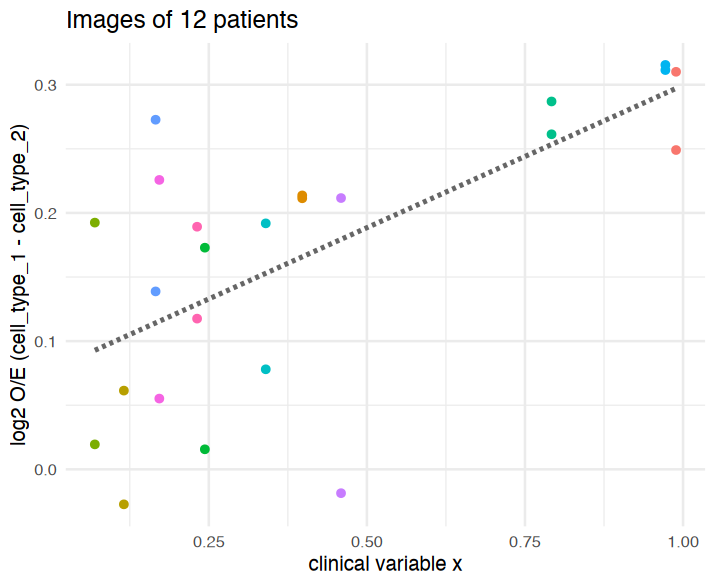

In [20]:
pp <- subset(per_image_c, cluster_i == "cell_type_1" & cluster_j == "cell_type_2")
pp$x <- x[pp$patient]
options(repr.plot.width = 5.5, repr.plot.height = 4.5)
ggplot(pp, aes(x, log2_oe)) + geom_point(aes(color = patient), show.legend = FALSE) +
  geom_smooth(method = "lm", se = FALSE, color = "grey40", linetype = "dashed") +
  labs(x = "clinical variable x", y = "log2 O/E (cell_type_1 - cell_type_2)", title = "Images of 12 patients") + theme_minimal()

In [21]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: aarch64-apple-darwin20 (64-bit)
Running under: macOS 26.3.1

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.11.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: Asia/Tokyo
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] patchwork_1.1.3       ggplot2_3.4.4         cohalu_0.99.3
[4] testthat_3.2.1       

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     rstudioapi_0.15.0      jsonlite_2.0.0        
  [4] magrittr_2.0.3         spatstat.utils_3.1-2   nloptr_2.0.3          
  [7] farver_2.1.1           fs_1.6.3               vctrs_0.6.5           
 [10] ROCR_1.0-11            minqa_1.2.6            Cairo_1.6-2   